# Part e 



Based on what we saw form the results in part a to d, the main issue is overfitting due to too little data an dcausing the class prediciton to collapse. We saw that both data augmentation sources improved the BERT model. So our idea for part e is to apply two target fixes together: a method built for tiny data, *SetFit*,  and to gradually incorporate more data.

We use the **setfit** package with **all-MiniLM-L6-v2**. To identify the most effective thechnique we compare four training configurations:

- using only the 32 labeled examples only
- using the 32 labeled examples plus the part b augmented data
- using the 32 labeled examples plus the part c synthetic data
- using the 32 labeled examples plus both the part b and c genereated data

This helps us isolate each augmentation source contribution on order to tell which ones gives is the most added value. All four scenarios are trained with the same SetFit setup:
- 5-fold CV for all four configurations
- CV rotates ONLY the real 32 examples;
- augmented/synthetic data is added to TRAINING each fold, never tested on
- and we evaluate in the same *7* real validation reviews

As we know, SetFit fine tunes a sentence-transforemer instead of a standard classification model. It trains in two stages, first it does 
the constrastive fine tuning of the encoder, which generates pairs of examples. For our case this means different rating pairs are pushed apart and similar rating pairs are pulled together. The advantage of this is that it has a multiplicative effect of the learning signal since it turns the 25 examples into hundreds of training pairs. The second aprt is a classifier head is trained on the resulting embeddings.

This method is well suited for tiny data since the pairwise training extracts much more signal from few labels and we start from a pretrained sentence embedding which means less to learn from scratch, which we hypothesize will reduce the overfitting seen in parts a to d.


**This code was based on class 6 and creasted with Claude code**


## setup

In [5]:
import os, sys

cwd = os.getcwd()
root = cwd
while not (os.path.isdir(os.path.join(root, "data")) and os.path.isdir(os.path.join(root, "scripts"))):
    parent = os.path.dirname(root)
    if parent == root:
        raise RuntimeError("Could not locate project root (folder with data/ and scripts/)")
    root = parent

os.chdir(root)                       # anchor cwd (prevents deleted-cwd FileNotFoundError)
sys.path.append(os.path.join(root, "scripts"))

REAL_CSV  = os.path.join(root, "data", "filtered_reviews.csv")
SYNTH_CSV = os.path.join(root, "data", "synthetic_filtered.csv")
AUG_CSV   = os.path.join(root, "data", "augmented_reviews.csv")
RESULTS_CSV = os.path.join(root, "data", "part_e_cv_results.csv")  # incremental save

print("root:", root)
print("REAL_CSV exists:", os.path.exists(REAL_CSV))
print("SYNTH_CSV exists:", os.path.exists(SYNTH_CSV))
print("AUG_CSV exists:", os.path.exists(AUG_CSV))


root: /Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final
REAL_CSV exists: True
SYNTH_CSV exists: True
AUG_CSV exists: True


In [6]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import mean_absolute_error, cohen_kappa_score
from datasets import Dataset
from setfit import SetFitModel, Trainer, TrainingArguments
from utils import Metrics, preprocess_for_bert

TEXT_COL, LABEL_COL = "review", "stars"
ST_MODEL = "sentence-transformers/all-MiniLM-L6-v2"

seed = 123

# version check — confirm the pinned, working SetFit stack before a long run
import setfit, sentence_transformers, transformers
print("setfit", setfit.__version__, "| sentence-transformers", sentence_transformers.__version__,
      "| transformers", transformers.__version__)


setfit 1.1.0 | sentence-transformers 3.2.1 | transformers 4.45.2


## Helper functions

In [7]:
def load_extra(path, sep=",", text_col="review", label_col="stars"):
    df = pd.read_csv(path, sep=sep)
    df = df.rename(columns={text_col: TEXT_COL, label_col: LABEL_COL})
    df[TEXT_COL] = df[TEXT_COL].apply(preprocess_for_bert)
    df = df.dropna(subset=[TEXT_COL, LABEL_COL])
    return df[TEXT_COL].tolist(), (df[LABEL_COL].astype(int) - 1).tolist()

def to_ds(texts, labels):
    return Dataset.from_dict({"text": list(texts), "label": list(labels)})

def train_setfit(train_texts, train_labels, valid_texts):
    # full SetFit: contrastive fine-tuning of the body + classifier head
    model = SetFitModel.from_pretrained(ST_MODEL)
    args = TrainingArguments(batch_size=16, num_epochs=1, num_iterations=20, seed=seed)
    trainer = Trainer(model=model, args=args,
                      train_dataset=to_ds(train_texts, train_labels),
                      column_mapping={"text": "text", "label": "label"})
    trainer.train()
    return [int(p) for p in trainer.model.predict(valid_texts)]

def setfit_cv(real_texts, real_labels, extra_texts=None, extra_labels=None,
              n_splits=5, label="SetFit", seed=seed):
    """5-fold stratified CV on the REAL data only. Extra (augmented/synthetic)
    data is added to TRAINING in every fold, never to the test fold. Pools
    predictions across folds, then runs them through metrics_val once."""
    extra_texts = extra_texts or []
    extra_labels = extra_labels or []
    real_texts = np.array(real_texts, dtype=object)
    real_labels = np.array(real_labels)

    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    all_true, all_pred = [], []
    for fold, (tr_idx, te_idx) in enumerate(skf.split(real_texts, real_labels), 1):
        print(f"  [{label}] Fold {fold}/{n_splits}")
        tr_t = real_texts[tr_idx].tolist() + list(extra_texts)
        tr_l = real_labels[tr_idx].tolist() + list(extra_labels)
        te_t = real_texts[te_idx].tolist()
        te_l = real_labels[te_idx].tolist()
        preds = train_setfit(tr_t, tr_l, te_t)
        all_true.extend(te_l)
        all_pred.extend(preds)
    metrics_val.run(all_true, all_pred, label)
    return all_true, all_pred


## Load the data

In [8]:
df = pd.read_csv(REAL_CSV)
df[TEXT_COL] = df[TEXT_COL].apply(preprocess_for_bert)
labeled = df.dropna(subset=[LABEL_COL, TEXT_COL]).reset_index(drop=True)
texts = labeled[TEXT_COL].tolist()
labels = (labeled[LABEL_COL].astype(int) - 1).tolist()

trt, valid_texts, trl, valid_labels = train_test_split(
    texts, labels, test_size=0.2, stratify=labels, random_state=seed)
n = min(32, len(trt))
try:
    rt, _, rl, _ = train_test_split(trt, trl, train_size=n, stratify=trl, random_state=seed)
except Exception:
    rt, rl = trt[:n], trl[:n]

syt, syl = load_extra(SYNTH_CSV)
at, al = load_extra(AUG_CSV, sep="\t", text_col="text", label_col="star_rating")
print(f"Real:{len(rt)} Aug(b):{len(at)} Synth(d):{len(syt)} Valid:{len(valid_texts)}")

Real:25 Aug(b):1000 Synth(d):909 Valid:7


## Train all four configurations

In [9]:
# 5-fold CV for all four configurations. CV rotates ONLY the real 32 examples;
# augmented/synthetic data is added to TRAINING each fold, never tested on.
# Results are saved to RESULTS_CSV after EACH config, so an overnight crash
# still leaves partial results on disk.

metrics_val = Metrics()

cv_configs = {
    "real only":           (None, None),
    "real + augmented(b)": (at, al),
    "real + synthetic(d)": (syt, syl),
    "real + both":         (at + syt, al + syl),
}

for name, (ex_t, ex_l) in cv_configs.items():
    print(f"\n=== SetFit 5-fold CV: {name} ===")
    setfit_cv(rt, rl, extra_texts=ex_t, extra_labels=ex_l, n_splits=5, label=name)
    # incremental save after each config completes
    pd.DataFrame(metrics_val.results).T.round(2).to_csv(RESULTS_CSV)
    print(f"  saved partial results -> {RESULTS_CSV}")

print("\nDONE. Final results:")
print(pd.DataFrame(metrics_val.results).T.round(2))



=== SetFit 5-fold CV: real only ===
  [real only] Fold 1/5


/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/sklearn/model_selection/_split.py:812: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Applying column mapping to the training dataset
/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/datasets/utils/_dill.py:379: DeprecationWarning: co_lnotab is deprecated, use co_lines instead.
  obj.co_lnotab,  # for < python 3.10 [not counted in args]


Map:   0%|          | 0/20 [00:00<?, ? examples/s]

***** Running training *****
  Num unique pairs = 800
  Batch size = 16
  Num epochs = 1


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/4823 [00:00<?, ?it/s]

/Users/camilanunezrodriguez/Documents/GitHub/advanced_nlp_final/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


{'embedding_loss': 0.2983, 'grad_norm': 1.960975170135498, 'learning_rate': 4.1407867494824025e-08, 'epoch': 0.0}
{'embedding_loss': 0.3073, 'grad_norm': 1.8148499727249146, 'learning_rate': 2.0703933747412013e-06, 'epoch': 0.01}
{'embedding_loss': 0.2548, 'grad_norm': 1.3178575038909912, 'learning_rate': 4.1407867494824025e-06, 'epoch': 0.02}
{'embedding_loss': 0.2283, 'grad_norm': 1.3951092958450317, 'learning_rate': 6.2111801242236025e-06, 'epoch': 0.03}
{'embedding_loss': 0.2092, 'grad_norm': 1.5552748441696167, 'learning_rate': 8.281573498964805e-06, 'epoch': 0.04}
{'embedding_loss': 0.1777, 'grad_norm': 1.729532241821289, 'learning_rate': 1.0351966873706005e-05, 'epoch': 0.05}
{'embedding_loss': 0.1609, 'grad_norm': 2.0197653770446777, 'learning_rate': 1.2422360248447205e-05, 'epoch': 0.06}
{'embedding_loss': 0.1491, 'grad_norm': 2.174649953842163, 'learning_rate': 1.4492753623188407e-05, 'epoch': 0.07}
{'embedding_loss': 0.1465, 'grad_norm': 1.5863654613494873, 'learning_rate': 

Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

{'embedding_loss': 0.1184, 'grad_norm': 1.169880747795105, 'learning_rate': 1.969124423963134e-05, 'epoch': 0.11}
{'embedding_loss': 0.1047, 'grad_norm': 2.5998597145080566, 'learning_rate': 1.946082949308756e-05, 'epoch': 0.12}
{'embedding_loss': 0.1082, 'grad_norm': 1.0586926937103271, 'learning_rate': 1.923041474654378e-05, 'epoch': 0.13}
{'embedding_loss': 0.098, 'grad_norm': 0.8237185478210449, 'learning_rate': 1.9e-05, 'epoch': 0.15}
{'embedding_loss': 0.1037, 'grad_norm': 0.8127058744430542, 'learning_rate': 1.8769585253456222e-05, 'epoch': 0.16}
{'embedding_loss': 0.0819, 'grad_norm': 1.672675371170044, 'learning_rate': 1.8539170506912446e-05, 'epoch': 0.17}
{'embedding_loss': 0.087, 'grad_norm': 1.872862696647644, 'learning_rate': 1.8308755760368666e-05, 'epoch': 0.18}
{'embedding_loss': 0.0876, 'grad_norm': 1.975433588027954, 'learning_rate': 1.8078341013824887e-05, 'epoch': 0.19}
{'embedding_loss': 0.0824, 'grad_norm': 1.035404086112976, 'learning_rate': 1.7847926267281108e-

# Results and plots

,Accuracy,Precision,Recall,F1-Score
real only,36.0,17.50,29.14,21.34
real + augmented(b),48.0,43.50,47.43,42.31
real + synthetic(d),60.0,67.17,57.29,57.33
real + both,64.0,64.67,61.14,61.98


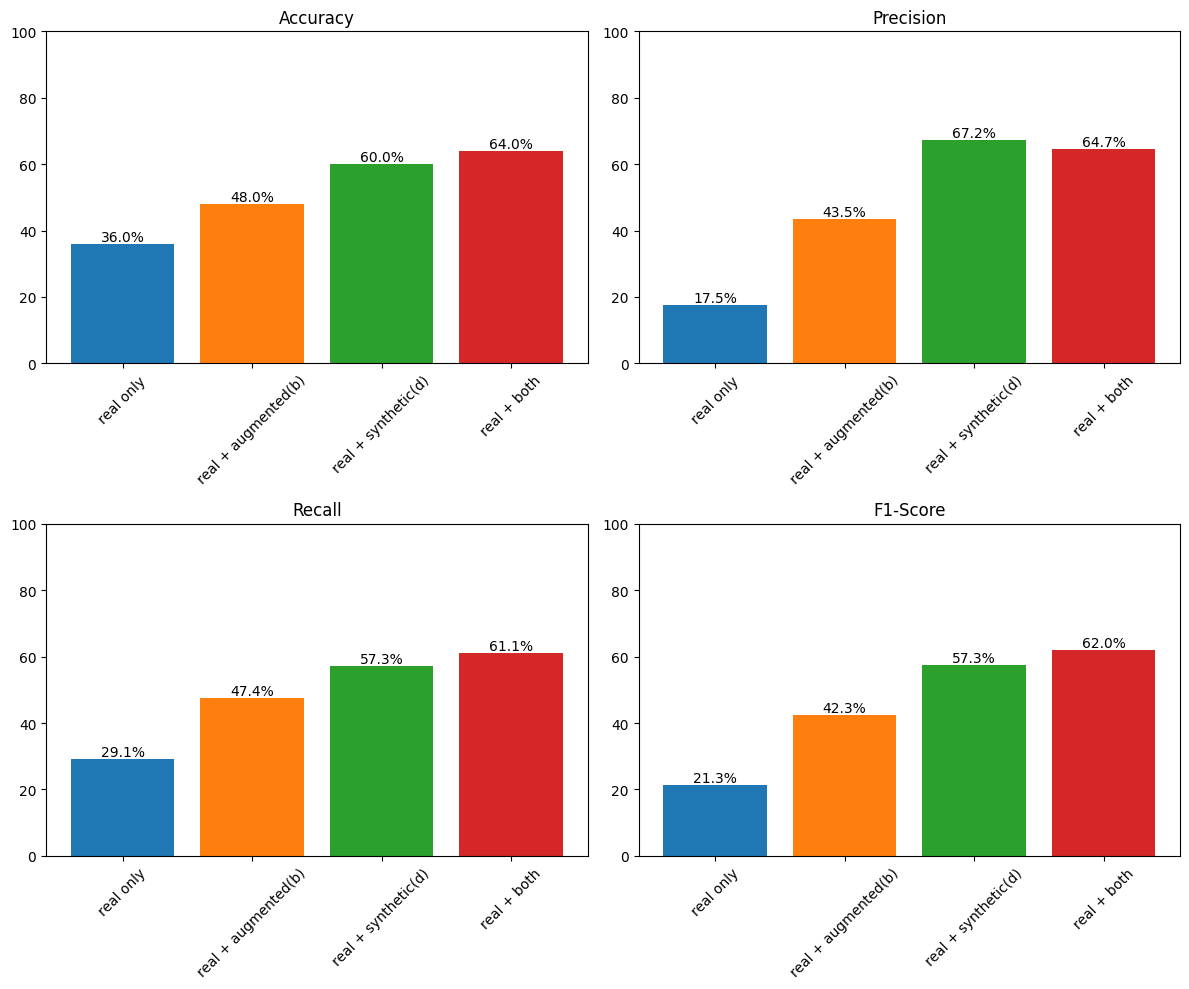

In [10]:
results = pd.DataFrame(metrics_val.results).T
display(results.round(2))
metrics_val.plot()


From this results we can clearly see that both augmenation data helped and combining them was best. Unlike what we saw in the other parts of the exercise "real + both" is the clear winner among the data settings on every metric. Moreover, we see that each data source helped individually. Both augmented and synthetic reached an F1 of 42.3 and 57.3 respectively  well above the F1 of 21.3 when we use the real labeled data. 

Another conclusion we reach from this results is, the two sources of geenrated data are complementary. Combining the, gives and F1 of 62 beating the F1 of either of them alone, meaning that they contribute different information rather than redundant signal. So the augmented reviews and synthetic ones cover cases that the other misses leading to more and varied data result rather than just more data.

We can see that recall and accuracy improve consistently as data is added, which is the expected results when giving a low data model more examples to learn from. The real data only recall grows from 29 to 60 with both sources and accuracy is bumped up from 36 to 64. Similarly, precision rises sharply with augmentatio as well, with a small drop from "real + synthetic" to "real + both". Because evaluation pools prediction across the 5 CV folds, the estimates are mosre stable than in a single split, but wit only 32 labels the metrics still carry some uncertainty, so we read the minor precision dip as noise rather than a real effect.






### Proposed improvements

- Bigger held out set: we can see this in part c where we use both the 7 and the 32 labeled data, even though the model is different, we can see how unstable the model is and  the clear improvement from enlarging the test set. A larger held out set of real labeled reviews would make the evaluation reliable.

- Invest in middle ratings: we saw the models struggle the most on the middle ratings, so generating more synthetic data for these classes and using an ordinal loss that respects the star ordering  would target this issue.

- Varied augmentatio: we could add richer data such as back translated data which could add useful signal.